In [1]:
!git clone https://github.com/dhruvmenon76/Pneumonia-Detection-Under-Imaging-Constraints.git

Cloning into 'Pneumonia-Detection-Under-Imaging-Constraints'...
remote: Enumerating objects: 5932, done.
remote: Counting objects: 100% (79/79), done.
remote: Compressing objects: 100% (69/69), done.
remote: Total 5932 (delta 28), reused 36 (delta 8), pack-reused 5853 (from 1)
Receiving objects: 100% (5932/5932), 1.16 GiB | 27.91 MiB/s, done.
Resolving deltas: 100% (33/33), done.
Updating files: 100% (5884/5884), done.


In [2]:
import sys
import os
import torch
import numpy as np
import matplotlib.pyplot as plt

!ls Pneumonia-Detection-Under-Imaging-Constraints/data
%cd /content/Pneumonia-Detection-Under-Imaging-Constraints

test  train  val
/content/Pneumonia-Detection-Under-Imaging-Constraints


In [3]:
sys.path.append(os.path.abspath("src"))
!pwd

/content/Pneumonia-Detection-Under-Imaging-Constraints


In [4]:
sys.path.append(os.path.abspath("src"))
from dataset_generation import get_dataloaders

In [5]:
import sys
print(sys.path[:5])

['/content', '/env/python', '/usr/lib/python312.zip', '/usr/lib/python3.12', '/usr/lib/python3.12/lib-dynload']


In [6]:
BASE_PATH = '/content/Pneumonia-Detection-Under-Imaging-Constraints/data'
print('Folders in data:', os.listdir(BASE_PATH))

train_loader, val_loader, test_loader = get_dataloaders(BASE_PATH, batch_size=32)
print('Train:', len(train_loader.dataset))
print('Val  :', len(val_loader.dataset))
print('Test :', len(test_loader.dataset))

Folders in data: ['train', 'test', '.DS_Store', 'val']
Train: 5216
Val  : 16
Test : 624


Batch shape: torch.Size([32, 3, 224, 224])


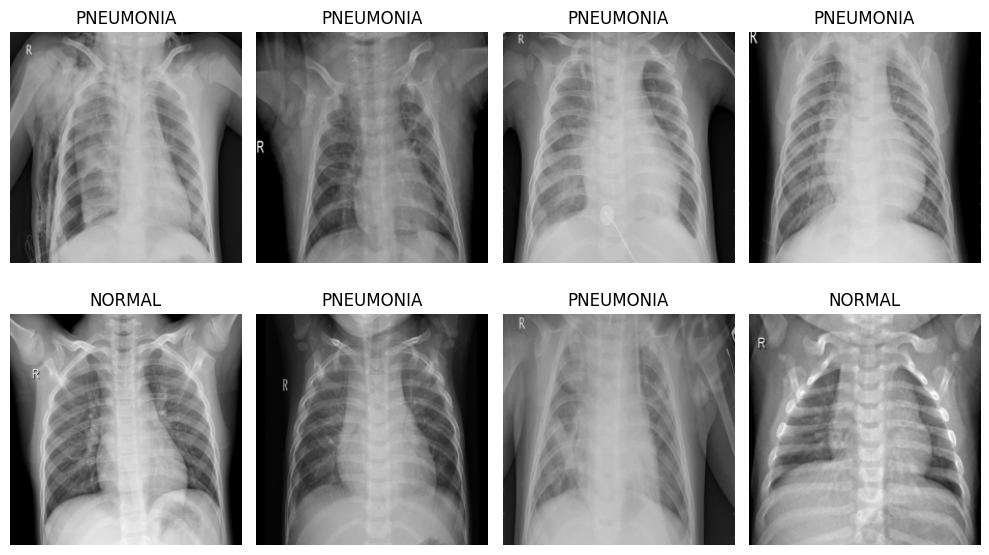

In [7]:
images, labels = next(iter(train_loader))
print('Batch shape:', images.shape)

def imshow(img):
    img = img.permute(1, 2, 0) * 0.5 + 0.5
    plt.imshow(img)
    plt.axis('off')

plt.figure(figsize=(10, 6))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    imshow(images[i])
    plt.title('PNEUMONIA' if labels[i].item() == 1 else 'NORMAL')
plt.tight_layout()
plt.show()

In [8]:
def print_class_dist(loader, name):
    lbl = np.array(loader.dataset.labels)
    total = len(lbl)
    n = np.sum(lbl == 0)
    p = np.sum(lbl == 1)
    print(f'\n{name} SET  total={total}  NORMAL={n} ({n/total:.1%})  PNEUMONIA={p} ({p/total:.1%})')

print_class_dist(train_loader, 'TRAIN')
print_class_dist(val_loader,   'VAL')
print_class_dist(test_loader,  'TEST')


TRAIN SET  total=5216  NORMAL=1341 (25.7%)  PNEUMONIA=3875 (74.3%)

VAL SET  total=16  NORMAL=8 (50.0%)  PNEUMONIA=8 (50.0%)

TEST SET  total=624  NORMAL=234 (37.5%)  PNEUMONIA=390 (62.5%)


In [9]:
def to_gray(t):
    return np.mean(t.cpu().permute(1, 2, 0).numpy(), axis=2)

def add_poisson_noise_xray(image, dose_scale, normalize=True):
    """
    Simulate xray noise using Poisson statistics.

    Parameters:
        image (np.ndarray): Input xray image (float or int)
        dose_scale (float): Relative dose level (1.0 = original, <1 = lower dose)
        normalize (bool): Whether to normalize image before noise

    Returns:
        noisy_image (np.ndarray): Image with simulated Poisson noise
    """

    # Convert to float
    image = image.astype(np.float32)

    # Normalize to [0, 1] if needed
    if normalize:
        img_min, img_max = image.min(), image.max()
        image_norm = (image - img_min) / (img_max - img_min + 1e-8)
    else:
        image_norm = image.copy()

    # Scale intensities by dose
    scaled = image_norm * dose_scale

    # Avoid zeros (Poisson lambda must be > 0)
    scaled = np.clip(scaled, 1e-8, None)

    # Apply Poisson noise
    noisy = np.random.poisson(scaled * 1e4) / 1e4

    # Rescale back
    if normalize:
        noisy = noisy * (img_max - img_min) + img_min

    return noisy

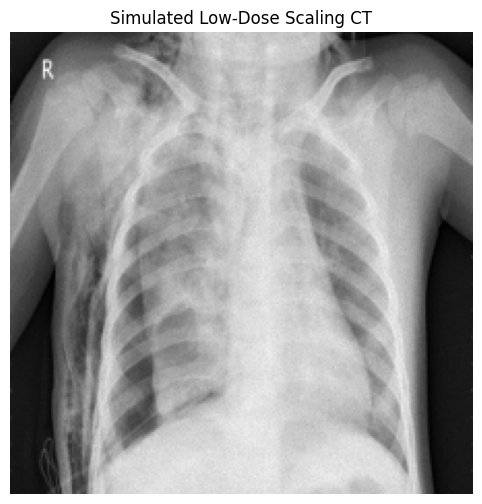

In [10]:
low_dose_image = add_poisson_noise_xray(to_gray(images[0]), dose_scale=0.4914)
plt.figure(figsize=(12, 6))
plt.imshow(low_dose_image, cmap='gray')
plt.title('Simulated Low-Dose Scaling CT')
plt.axis('off')
plt.show()

Noise ∝ 1 / sqrt(dose)

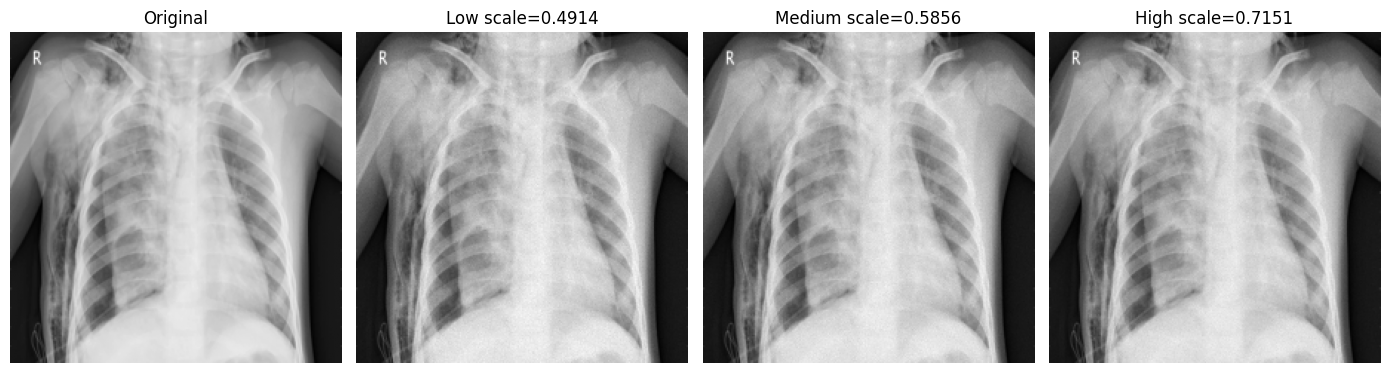

In [11]:
img_gray = to_gray(images[0])
#Noise parameters found using SSIM metric
configs  = [('Low scale=0.4914', .4914), ('Medium scale=0.5856', 0.5856), ('High scale=0.7151', 0.7151)]

plt.figure(figsize=(14, 4))
plt.subplot(1, 4, 1)
plt.title('Original')
plt.imshow(img_gray, cmap='gray')
plt.axis('off')

for idx, (title, sigma) in enumerate(configs, 2):
    dosed_image = add_poisson_noise_xray(img_gray, dose_scale=sigma)
    plt.subplot(1, 4, idx)
    plt.title(title)
    plt.imshow(dosed_image, cmap='gray')
    plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
DOSE_LEVELS = {
    'low_dose' : {'scale': 0.1},
    'medium_dose' : {'scale': 0.3},
    'high_dose' : {'scale': 0.75}
}

SPLITS  = ['train', 'val', 'test']
CLASSES = ['NORMAL', 'PNEUMONIA']

In [ ]:
def dose_pil(img, params):
    """
    Convert PIL image to grayscale, apply Poisson dose noise,
    and return a PIL image ready to save.
    """
    arr = np.asarray(img.convert('L'), dtype=np.float32)
    dosed = add_poisson_noise_xray(arr, dose_scale=params['scale'])
    dosed = np.clip(dosed, 0, 255).astype(np.uint8)
    return Image.fromarray(dosed, mode='L')


def _process_one(task):
    """
    Worker function for multiprocessing.
    """
    src_path, dst_path, params, overwrite = task

    if dst_path.exists() and not overwrite:
        return 0

    with Image.open(src_path) as img:
        out_img = dose_pil(img, params)
        out_img.save(dst_path, format='PNG', compress_level=1)

    return 1


In [14]:
from pathlib import Path
from PIL import Image
import numpy as np
import os
from concurrent.futures import ProcessPoolExecutor
from tqdm.auto import tqdm

def generate(base_path, overwrite=False, num_workers=None):
    """
    Generate dose-varied datasets in parallel.

    Parameters
    ----------
    base_path : str or Path
        Root dataset folder containing train/val/test.
    overwrite : bool
        Whether to overwrite existing generated images.
    num_workers : int or None
        Number of CPU worker processes. If None, picks a sensible default.
    """
    base = Path(base_path)

    if num_workers is None:
        cpu_total = os.cpu_count() or 2
        num_workers = max(1, min(8, cpu_total - 1))

    tasks = []

    for level, params in DOSE_LEVELS.items():
        for split in SPLITS:
            for cls in CLASSES:
                src_dir = base / split / cls
                dst_dir = base / level / split / cls
                dst_dir.mkdir(parents=True, exist_ok=True)

                files = []
                for ext in ('*.jpeg', '*.jpg', '*.png'):
                    files.extend(src_dir.glob(ext))

                for fp in files:
                    out = dst_dir / f"{fp.stem}.png"
                    tasks.append((fp, out, params, overwrite))

    print(f"Prepared {len(tasks)} files across {len(DOSE_LEVELS)} dose levels.")
    print(f"Using {num_workers} worker processes.")

    written = 0
    with ProcessPoolExecutor(max_workers=num_workers) as executor:
        for result in tqdm(executor.map(_process_one, tasks, chunksize=32), total=len(tasks)):
            written += result

    print(f"Finished. Wrote {written} files.")

In [15]:
BASE_PATH = '/content/Pneumonia-Detection-Under-Imaging-Constraints/data'
generate(BASE_PATH, overwrite=True)

Prepared 17568 files across 3 dose levels.
Using 8 worker processes.


  0%|          | 0/17568 [00:00<?, ?it/s]

/tmp/ipykernel_7764/1522042601.py:9: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(dosed, mode='L')
/tmp/ipykernel_7764/1522042601.py:9: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(dosed, mode='L')
/tmp/ipykernel_7764/1522042601.py:9: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(dosed, mode='L')
/tmp/ipykernel_7764/1522042601.py:9: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(dosed, mode='L')
/tmp/ipykernel_7764/1522042601.py:9: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(dosed, mode='L')
/tmp/ipykernel_7764/1522042601.py:9: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13

Finished. Wrote 17568 files.


In [16]:
def count(path):
    p = Path(path)
    return len(list(p.glob('*.jpeg')) + list(p.glob('*.jpg')) + list(p.glob('*.png')))

base = Path(BASE_PATH)
datasets = ['original'] + list(DOSE_LEVELS.keys())
print(f"{'Dataset':<20} {'Split':<8} {'NORMAL':>8} {'PNEUMONIA':>12} {'Total':>8}")
print('='*60)
for ds in datasets:
    for split in SPLITS:
        prefix = base if ds == 'original' else base / ds
        n = count(prefix / split / 'NORMAL')
        p = count(prefix / split / 'PNEUMONIA')
        print(f'{ds:<20} {split:<8} {n:>8} {p:>12} {n+p:>8}')
    print('-'*60)


Dataset              Split      NORMAL    PNEUMONIA    Total
original             train        1341         3875     5216
original             val             8            8       16
original             test          234          390      624
------------------------------------------------------------
low_dose             train        1341         3875     5216
low_dose             val             8            8       16
low_dose             test          234          390      624
------------------------------------------------------------
medium_dose          train        1341         3875     5216
medium_dose          val             8            8       16
medium_dose          test          234          390      624
------------------------------------------------------------
high_dose            train        1341         3875     5216
high_dose            val             8            8       16
high_dose            test          234          390      624
------------------------

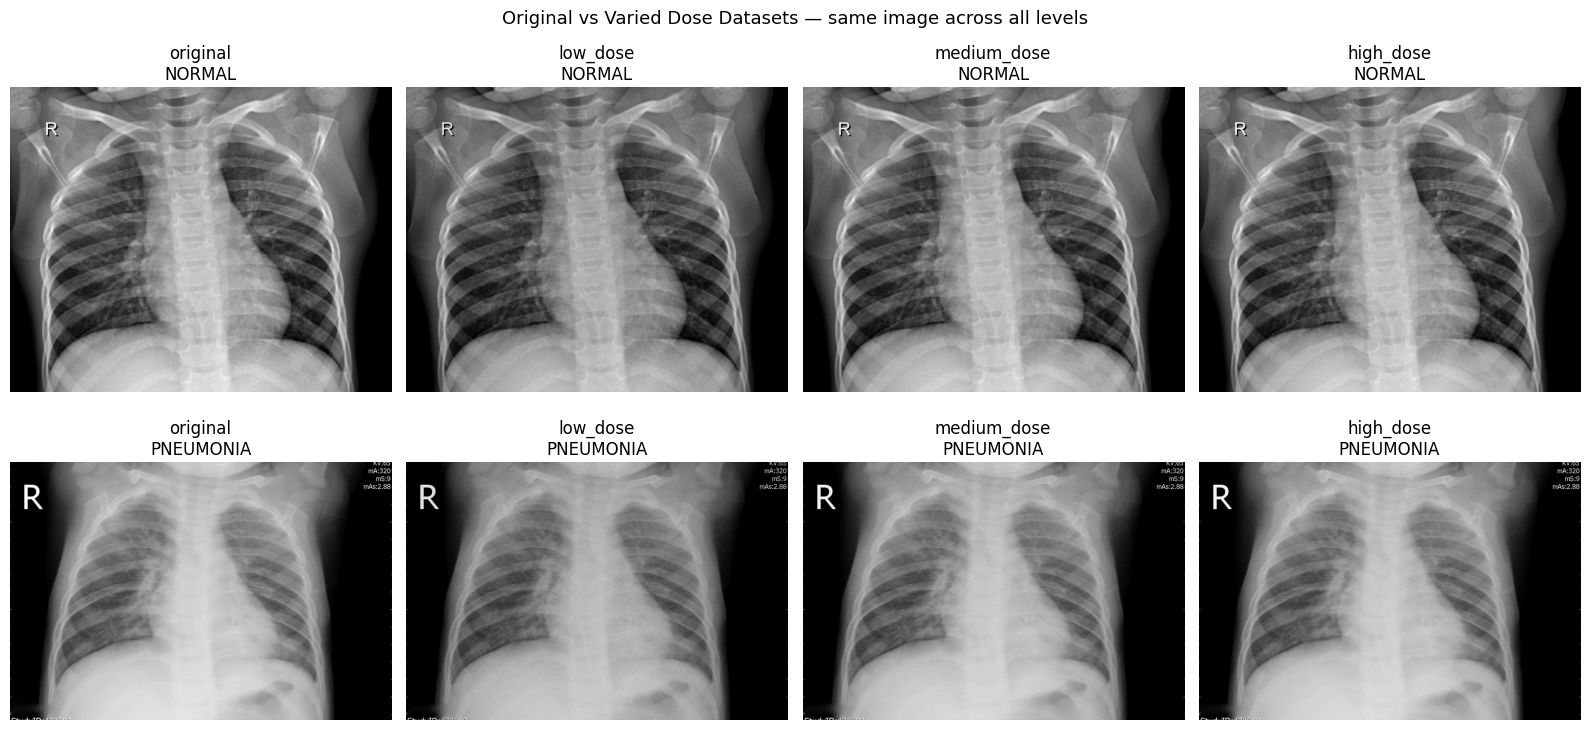

In [17]:
BASE = '/content/Pneumonia-Detection-Under-Imaging-Constraints/data'

sample_normal    = list((Path(BASE) / 'test' / 'NORMAL').glob('*.jpeg'))[4]
sample_pneumonia = list((Path(BASE) / 'test' / 'PNEUMONIA').glob('*.jpeg'))[4]

datasets = ['original', 'low_dose', 'medium_dose', 'high_dose']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for col, ds in enumerate(datasets):
    # NORMAL row
    if ds == 'original':
        path_n = sample_normal
    else:
        path_n = Path(BASE) / ds / 'test' / 'NORMAL' / f'{sample_normal.stem}.png'

    axes[0, col].imshow(Image.open(path_n).convert('L'), cmap='gray')
    axes[0, col].set_title(f'{ds}\nNORMAL')
    axes[0, col].axis('off')

    # PNEUMONIA row
    if ds == 'original':
        path_p = sample_pneumonia
    else:
        path_p = Path(BASE) / ds / 'test' / 'PNEUMONIA' / f'{sample_pneumonia.stem}.png'

    axes[1, col].imshow(Image.open(path_p).convert('L'), cmap='gray')
    axes[1, col].set_title(f'{ds}\nPNEUMONIA')
    axes[1, col].axis('off')

plt.suptitle('Original vs Varied Dose Datasets — same image across all levels', fontsize=13)
plt.tight_layout()
plt.show()

## Evaluate with Baseline Model

In [18]:
import os
import torch
import torch.nn as nn
from torchvision.models import densenet121


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Rebuild model architecture
model = densenet121(weights=None)
in_features = model.classifier.in_features
model.classifier = nn.Linear(in_features, 2)
model = model.to(device)

# Load saved weights
weights_path = "/content/Pneumonia-Detection-Under-Imaging-Constraints/results/baseline_densenet_classweighted/model_weights.pth"

state_dict = torch.load(weights_path, map_location=device)
model.load_state_dict(state_dict)
model.eval()

print("Model weights loaded successfully.")

Using device: cuda
Model weights loaded successfully.


In [19]:
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

def evaluate_model_full(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            probs = torch.softmax(outputs, dim=1)[:, 1]
            preds = torch.argmax(outputs, dim=1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    accuracy = accuracy_score(all_labels, all_preds)
    bal_acc = balanced_accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, zero_division=0)
    recall = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)

    if len(np.unique(all_labels)) == 2:
        auc = roc_auc_score(all_labels, all_probs)
    else:
        auc = np.nan

    cm = confusion_matrix(all_labels, all_preds)

    return {
        "loss": epoch_loss,
        "accuracy": accuracy,
        "balanced_accuracy": bal_acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "auc": auc,
        "confusion_matrix": cm,
        "labels": np.array(all_labels),
        "preds": np.array(all_preds),
        "probs": np.array(all_probs),
    }

In [ ]:
num_normal = 1341
num_pneumonia = 3875
total = num_normal + num_pneumonia

weight_normal = total / (2 * num_normal)
weight_pneumonia = total / (2 * num_pneumonia)

class_weights = torch.tensor(
    [weight_normal, weight_pneumonia],
    dtype=torch.float32
).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

In [21]:
dose_roots = {
    "low_dose": os.path.join(BASE_PATH, "low_dose"),
    "medium_dose": os.path.join(BASE_PATH, "medium_dose"),
    "high_dose": os.path.join(BASE_PATH, "high_dose"),
    "original": BASE_PATH
}

results = {}

for name, root in dose_roots.items():
    print(f"\nEvaluating on: {name}")
    _, _, test_loader_mod = get_dataloaders(root, batch_size=32)

    metrics = evaluate_model_full(model, test_loader_mod, criterion, device)
    results[name] = metrics

    # print(f"Loss              : {metrics['loss']:.4f}")
    # print(f"Accuracy          : {metrics['accuracy']:.4f}")
    # print(f"Balanced Accuracy : {metrics['balanced_accuracy']:.4f}")
    # print(f"Precision         : {metrics['precision']:.4f}")
    # print(f"Recall            : {metrics['recall']:.4f}")
    # print(f"F1                : {metrics['f1']:.4f}")
    # print(f"AUC               : {metrics['auc']:.4f}")
    # print("Confusion Matrix:")
    # print(metrics["confusion_matrix"])




Evaluating on: low_dose

Evaluating on: medium_dose

Evaluating on: high_dose

Evaluating on: original



Dataset      Accuracy       F1      AUC   Recall  Precision    Bal Acc
low_dose       0.6250   0.7692   0.7300   1.0000     0.6250     0.5000
medium_dose     0.6250   0.7692   0.6703   1.0000     0.6250     0.5000
high_dose      0.6346   0.7738   0.9266   1.0000     0.6311     0.5128
original       0.7933   0.8562   0.9336   0.9846     0.7574     0.7295


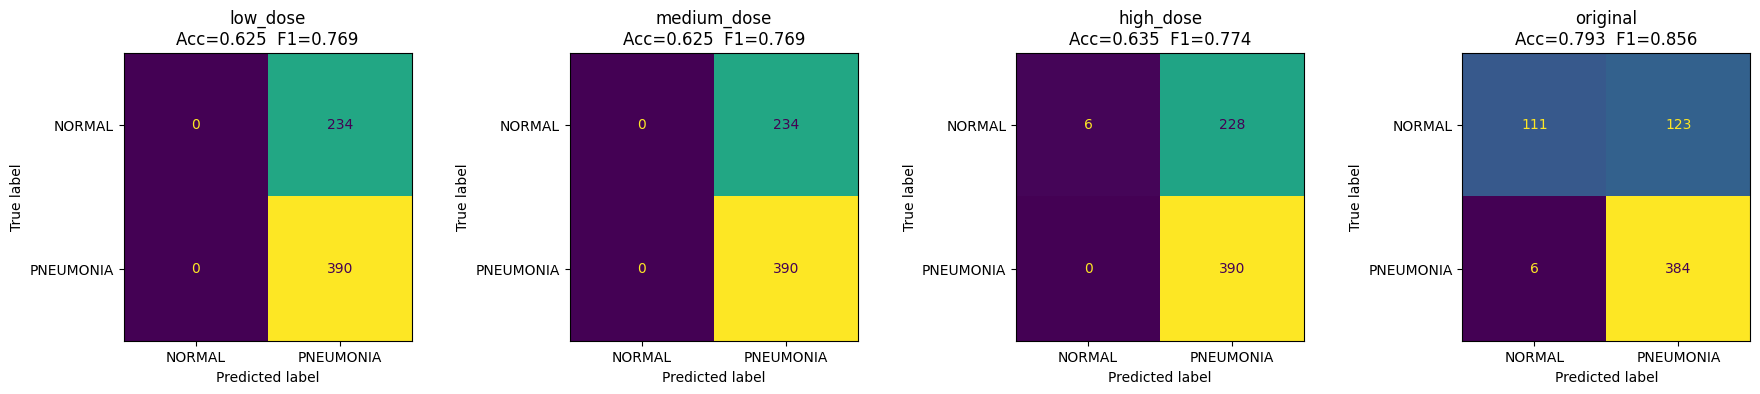

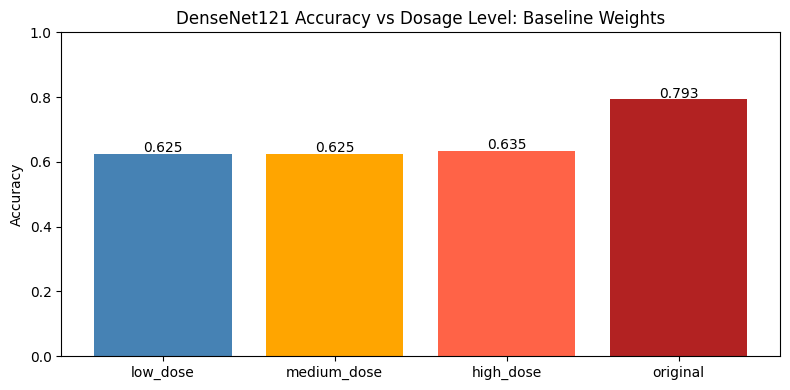

In [22]:
from sklearn.metrics import ConfusionMatrixDisplay, balanced_accuracy_score

def display_results(results, title):
    # Summary table
    print(f"\n{'Dataset':<10} {'Accuracy':>10} {'F1':>8} {'AUC':>8} {'Recall':>8} {'Precision':>10} {'Bal Acc':>10}")
    print('='*70)
    for name, r in results.items():
        print(f"{name:<10} {r['accuracy']:>10.4f} {r['f1']:>8.4f} "
            f"{r['auc']:>8.4f} {r['recall']:>8.4f} {r['precision']:>10.4f} {r['balanced_accuracy']:>10.4f}")

    # Confusion matrices
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    for ax, (name, r) in zip(axes, results.items()):
        ConfusionMatrixDisplay(r['confusion_matrix'], display_labels=['NORMAL', 'PNEUMONIA']).plot(ax=ax, colorbar=False)
        ax.set_title(f"{name}\nAcc={r['accuracy']:.3f}  F1={r['f1']:.3f}")
    plt.tight_layout()
    plt.show()

    # Accuracy drop bar chart
    plt.figure(figsize=(8, 4))
    names = list(results.keys())
    accs  = [results[n]['accuracy'] for n in names]
    bars  = plt.bar(names, accs, color=['steelblue', 'orange', 'tomato', 'firebrick'])
    for bar, acc in zip(bars, accs):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{acc:.3f}', ha='center')
    plt.ylim(0, 1)
    plt.ylabel('Accuracy')
    plt.title(f'DenseNet121 Accuracy vs Dosage Level: {title}')
    plt.tight_layout()
    plt.show()

display_results(results, "Baseline Weights")

## Display Metrics for Baseline vs Modified Images

In [23]:
import pandas as pd

summary = pd.DataFrame({
    name: {
        "loss": m["loss"],
        "accuracy": m["accuracy"],
        "balanced_accuracy": m["balanced_accuracy"],
        "precision": m["precision"],
        "recall": m["recall"],
        "f1": m["f1"],
        "auc": m["auc"],
    }
    for name, m in results.items()
}).T

summary

,loss,accuracy,balanced_accuracy,precision,recall,f1,auc
low_dose,5.396510,0.625000,0.500000,0.625000,1.000000,0.769231,0.730035
medium_dose,3.285277,0.625000,0.500000,0.625000,1.000000,0.769231,0.670299
high_dose,2.153070,0.634615,0.512821,0.631068,1.000000,0.773810,0.926611
original,0.816385,0.793269,0.729487,0.757396,0.984615,0.856187,0.933574


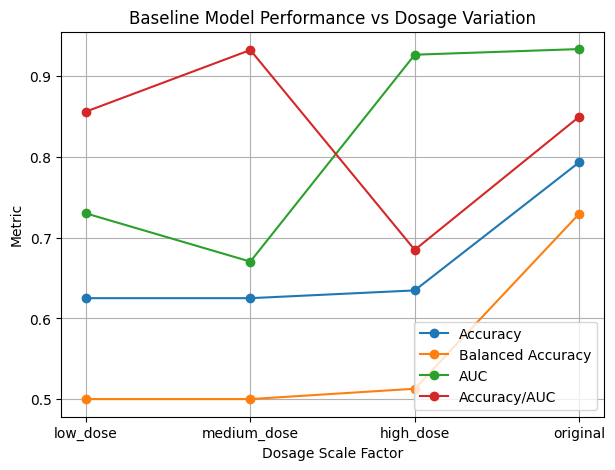

In [24]:
import matplotlib.pyplot as plt


plt.figure(figsize=(7, 5))
plt.plot(summary.index, summary["accuracy"], marker="o", label="Accuracy")
plt.plot(summary.index, summary["balanced_accuracy"], marker="o", label="Balanced Accuracy")
plt.plot(summary.index, summary["auc"], marker="o", label="AUC")
plt.plot(summary.index, summary["accuracy"]/summary["auc"], marker="o", label="Accuracy/AUC")

plt.xlabel("Dosage Scale Factor")
plt.ylabel("Metric")
plt.title("Baseline Model Performance vs Dosage Variation")
plt.legend()
plt.grid(True)
plt.show()

## Retrain Model with Degraded Images

In [25]:
import os
import copy
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
from torchvision.models import densenet121

def build_model(weights_path, device):
    model = densenet121(weights=None)
    model.classifier = nn.Linear(model.classifier.in_features, 2)
    model.load_state_dict(torch.load(weights_path, map_location=device))
    model = model.to(device)
    return model


def get_class_weights_from_loader(loader, device):
    labels = np.array(loader.dataset.labels)
    num_normal = np.sum(labels == 0)
    num_pneumonia = np.sum(labels == 1)
    total = len(labels)

    class_weights = torch.tensor(
        [total / (2 * num_normal), total / (2 * num_pneumonia)],
        dtype=torch.float32,
        device=device
    )
    return class_weights


def fine_tune_on_dataset(
    train_root,
    weights_path,
    device,
    batch_size=32,
    num_epochs=8,
    lr=1e-4
):
    train_loader, val_loader, test_loader = get_dataloaders(train_root, batch_size=batch_size)

    class_weights = get_class_weights_from_loader(train_loader, device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    model = build_model(weights_path, device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_loss = float("inf")

    history = []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        running_correct = 0
        total_seen = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            running_correct += (torch.argmax(outputs, dim=1) == labels).sum().item()
            total_seen += labels.size(0)

        train_loss = running_loss / len(train_loader.dataset)
        train_acc = running_correct / total_seen

        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_seen = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                val_correct += (torch.argmax(outputs, dim=1) == labels).sum().item()
                val_seen += labels.size(0)

        val_loss /= len(val_loader.dataset)
        val_acc = val_correct / val_seen

        history.append({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
        })

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_wts = copy.deepcopy(model.state_dict())

        print(
            f"Epoch {epoch+1:02d}/{num_epochs} | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
        )

    model.load_state_dict(best_model_wts)
    return model, criterion, pd.DataFrame(history)

In [26]:
def train_and_evaluate_all_domains(
    train_condition,
    dose_roots,
    weights_path,
    device,
    batch_size=32,
    num_epochs=8,
    lr=1e-4
):
    print(f"\n{'='*70}")
    print(f"Training on: {train_condition}")
    print(f"{'='*70}")

    train_root = dose_roots[train_condition]

    model, criterion, history = fine_tune_on_dataset(
        train_root=train_root,
        weights_path=weights_path,
        device=device,
        batch_size=batch_size,
        num_epochs=num_epochs,
        lr=lr
    )

    eval_results = {}

    for test_condition, test_root in dose_roots.items():
        print(f"\nTesting on: {test_condition}")
        _, _, test_loader = get_dataloaders(test_root, batch_size=batch_size)

        metrics = evaluate_model_full(model, test_loader, criterion, device)
        eval_results[test_condition] = metrics

        print(f"Loss              : {metrics['loss']:.4f}")
        print(f"Accuracy          : {metrics['accuracy']:.4f}")
        print(f"Balanced Accuracy : {metrics['balanced_accuracy']:.4f}")
        print(f"Precision         : {metrics['precision']:.4f}")
        print(f"Recall            : {metrics['recall']:.4f}")
        print(f"F1                : {metrics['f1']:.4f}")
        print(f"AUC               : {metrics['auc']:.4f}")
        print("Confusion Matrix:")
        print(metrics["confusion_matrix"])

    return model, history, eval_results

In [27]:
all_histories = {}
all_eval_results = {}
all_models = {}

training_conditions = ["original", "low_dose", "medium_dose", "high_dose"]

for train_condition in training_conditions:
    model_ft, history_df, eval_results = train_and_evaluate_all_domains(
        train_condition=train_condition,
        dose_roots=dose_roots,
        weights_path=weights_path,
        device=device,
        batch_size=32,
        num_epochs=8,
        lr=1e-4
    )

    all_models[train_condition] = model_ft
    all_histories[train_condition] = history_df
    all_eval_results[train_condition] = eval_results


Training on: original
Epoch 01/8 | Train Loss: 0.0306 | Train Acc: 0.9895 | Val Loss: 0.0915 | Val Acc: 1.0000
Epoch 02/8 | Train Loss: 0.0187 | Train Acc: 0.9933 | Val Loss: 0.2529 | Val Acc: 0.8750
Epoch 03/8 | Train Loss: 0.0254 | Train Acc: 0.9885 | Val Loss: 0.2050 | Val Acc: 0.9375
Epoch 04/8 | Train Loss: 0.0202 | Train Acc: 0.9944 | Val Loss: 1.0022 | Val Acc: 0.6875
Epoch 05/8 | Train Loss: 0.0279 | Train Acc: 0.9914 | Val Loss: 0.0407 | Val Acc: 1.0000
Epoch 06/8 | Train Loss: 0.0228 | Train Acc: 0.9927 | Val Loss: 0.2112 | Val Acc: 0.9375
Epoch 07/8 | Train Loss: 0.0153 | Train Acc: 0.9942 | Val Loss: 0.1442 | Val Acc: 0.9375
Epoch 08/8 | Train Loss: 0.0052 | Train Acc: 0.9987 | Val Loss: 0.5408 | Val Acc: 0.7500

Testing on: low_dose
Loss              : 5.6827
Accuracy          : 0.6250
Balanced Accuracy : 0.5000
Precision         : 0.6250
Recall            : 1.0000
F1                : 0.7692
AUC               : 0.5436
Confusion Matrix:
[[  0 234]
 [  0 390]]

Testing on: 

In [28]:
rows = []

for train_condition, test_dict in all_eval_results.items():
    for test_condition, m in test_dict.items():
        rows.append({
            "trained_on": train_condition,
            "tested_on": test_condition,
            "loss": m["loss"],
            "accuracy": m["accuracy"],
            "balanced_accuracy": m["balanced_accuracy"],
            "precision": m["precision"],
            "recall": m["recall"],
            "f1": m["f1"],
            "auc": m["auc"],
        })

results_df = pd.DataFrame(rows)
results_df

,trained_on,tested_on,loss,accuracy,balanced_accuracy,precision,recall,f1,auc
0,original,low_dose,5.682672,0.625000,0.500000,0.625000,1.000000,0.769231,0.543551
1,original,medium_dose,2.768592,0.625000,0.500000,0.625000,1.000000,0.769231,0.551342
2,original,high_dose,1.021130,0.735577,0.648291,0.703436,0.997436,0.825027,0.932512
3,original,original,0.772493,0.825321,0.771368,0.787321,0.987179,0.875995,0.934928
4,low_dose,low_dose,0.416994,0.841346,0.804701,0.822616,0.951282,0.882283,0.910158
5,low_dose,medium_dose,3.458042,0.620192,0.496154,0.623188,0.992308,0.765579,0.641913
6,low_dose,high_dose,14.265581,0.625000,0.500000,0.625000,1.000000,0.769231,0.498718
7,low_dose,original,21.570823,0.625000,0.500000,0.625000,1.000000,0.769231,0.500000
8,medium_dose,low_dose,1.906870,0.625000,0.500000,0.625000,1.000000,0.769231,0.582194
9,medium_dose,medium_dose,1.008038,0.788462,0.720513,0.750000,0.992308,0.854305,0.907681



Dataset      Accuracy       F1      AUC   Recall  Precision    Bal Acc
low_dose       0.6250   0.7692   0.5436   1.0000     0.6250     0.5000
medium_dose     0.6250   0.7692   0.5513   1.0000     0.6250     0.5000
high_dose      0.7356   0.8250   0.9325   0.9974     0.7034     0.6483
original       0.8253   0.8760   0.9349   0.9872     0.7873     0.7714


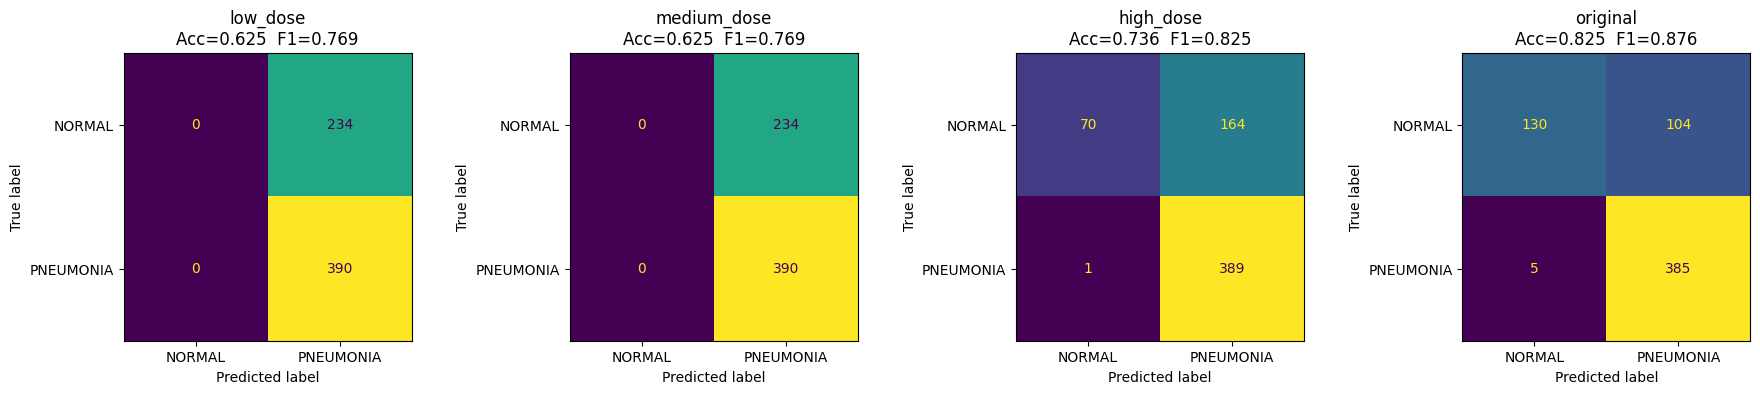

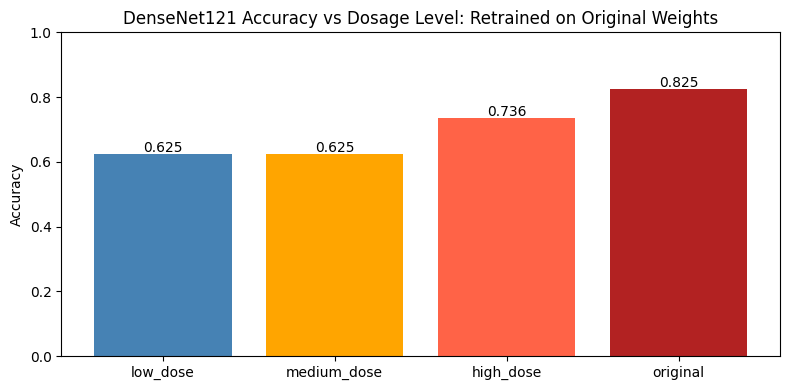


Dataset      Accuracy       F1      AUC   Recall  Precision    Bal Acc
low_dose       0.8413   0.8823   0.9102   0.9513     0.8226     0.8047
medium_dose     0.6202   0.7656   0.6419   0.9923     0.6232     0.4962
high_dose      0.6250   0.7692   0.4987   1.0000     0.6250     0.5000
original       0.6250   0.7692   0.5000   1.0000     0.6250     0.5000


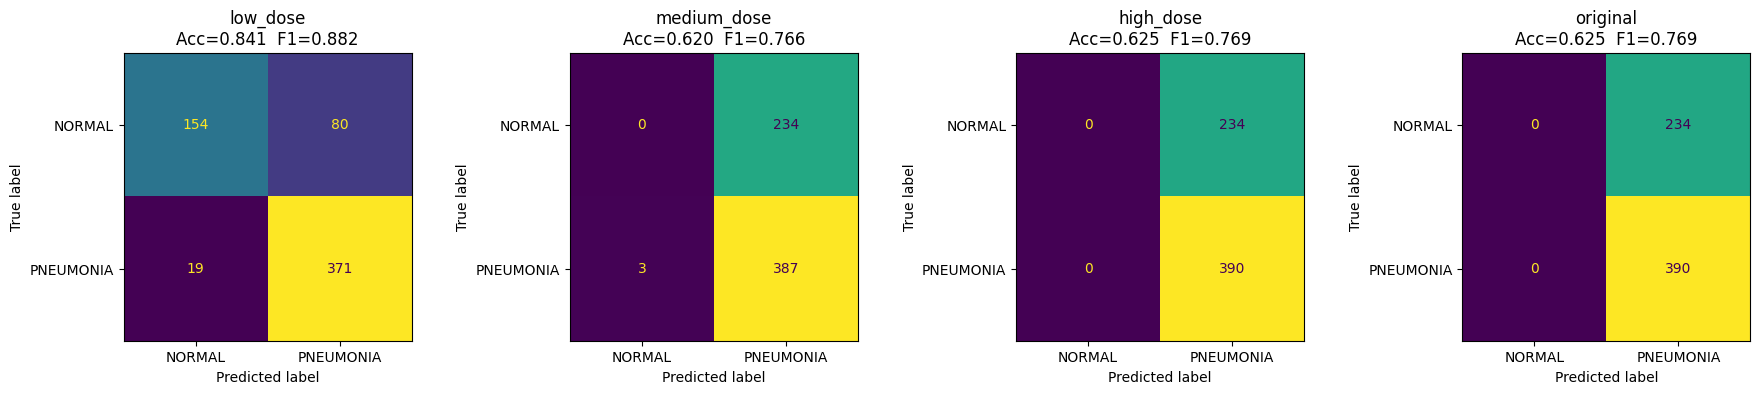

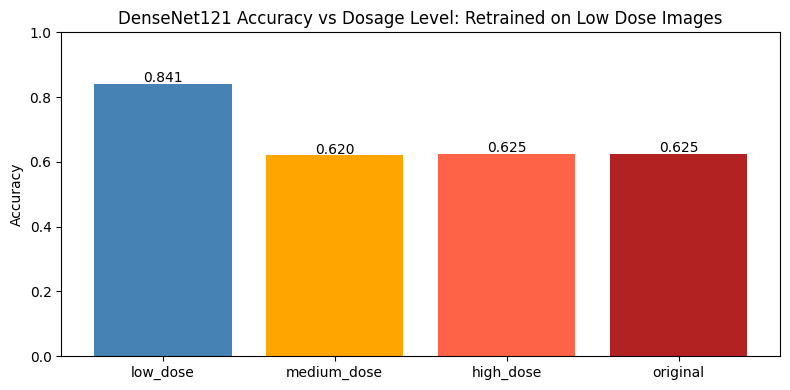


Dataset      Accuracy       F1      AUC   Recall  Precision    Bal Acc
low_dose       0.6250   0.7692   0.5822   1.0000     0.6250     0.5000
medium_dose     0.7885   0.8543   0.9077   0.9923     0.7500     0.7205
high_dose      0.3750   0.0000   0.5245   0.0000     0.0000     0.5000
original       0.3750   0.0000   0.5038   0.0000     0.0000     0.5000


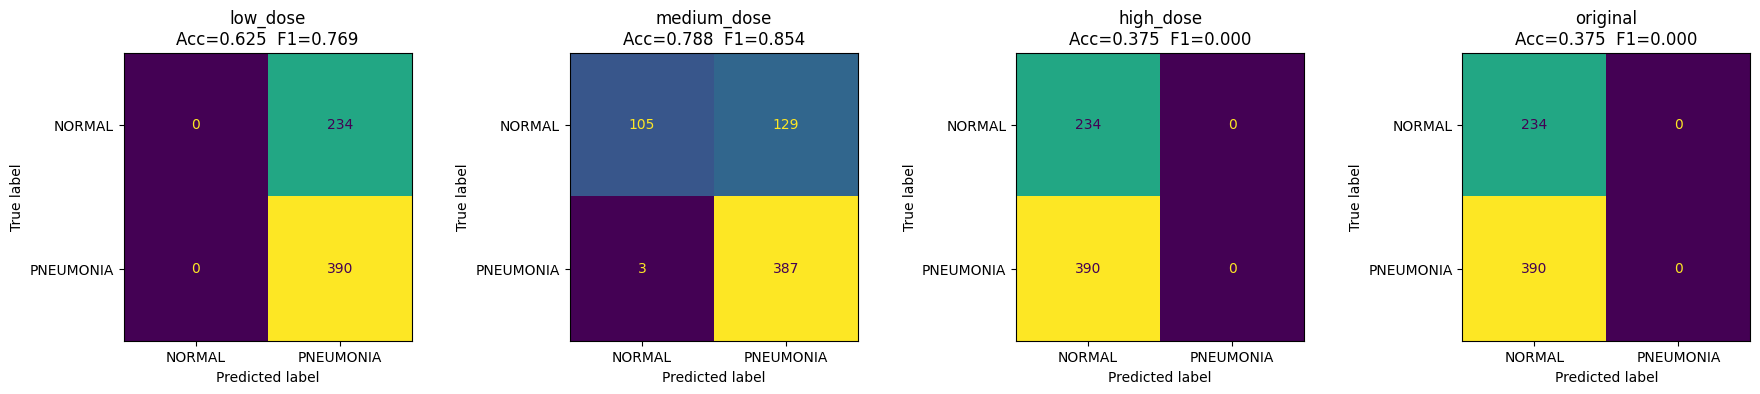

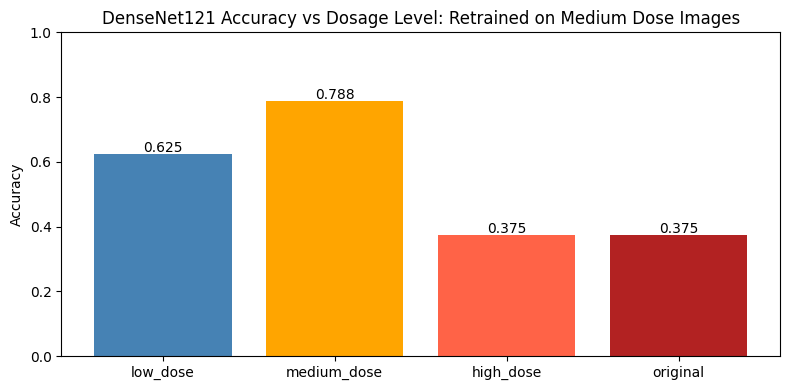


Dataset      Accuracy       F1      AUC   Recall  Precision    Bal Acc
low_dose       0.6250   0.7692   0.5168   1.0000     0.6250     0.5000
medium_dose     0.6250   0.7692   0.5806   1.0000     0.6250     0.5000
high_dose      0.8478   0.8889   0.9336   0.9744     0.8172     0.8056
original       0.5160   0.3734   0.9042   0.2308     0.9783     0.6111


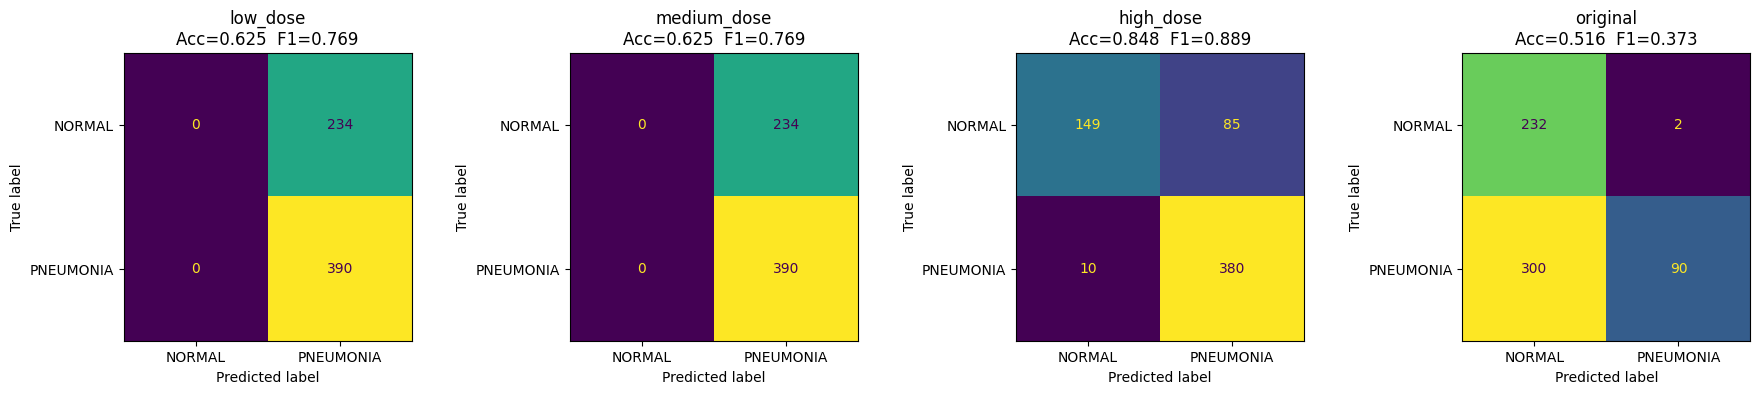

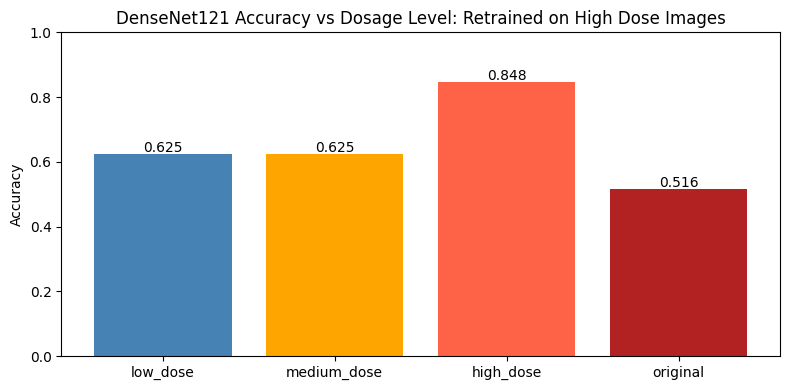

In [29]:
display_results(all_eval_results["original"], "Retrained on Original Weights")
display_results(all_eval_results["low_dose"], "Retrained on Low Dose Images")
display_results(all_eval_results["medium_dose"], "Retrained on Medium Dose Images")
display_results(all_eval_results["high_dose"], "Retrained on High Dose Images")

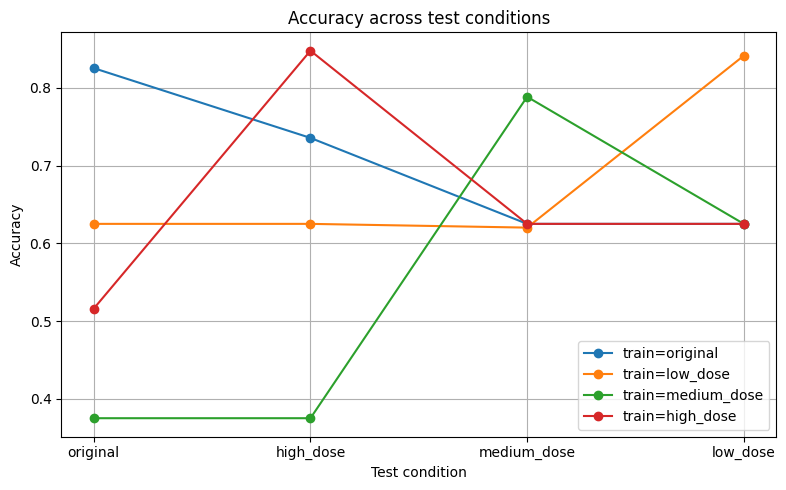

In [30]:
test_order = ["original", "high_dose", "medium_dose", "low_dose"]

plt.figure(figsize=(8, 5))
for train_condition in results_df["trained_on"].unique():
    subset = results_df[results_df["trained_on"] == train_condition].copy()
    subset["tested_on"] = pd.Categorical(subset["tested_on"], categories=test_order, ordered=True)
    subset = subset.sort_values("tested_on")

    plt.plot(subset["tested_on"], subset["accuracy"], marker="o", label=f"train={train_condition}")

plt.xlabel("Test condition")
plt.ylabel("Accuracy")
plt.title("Accuracy across test conditions")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

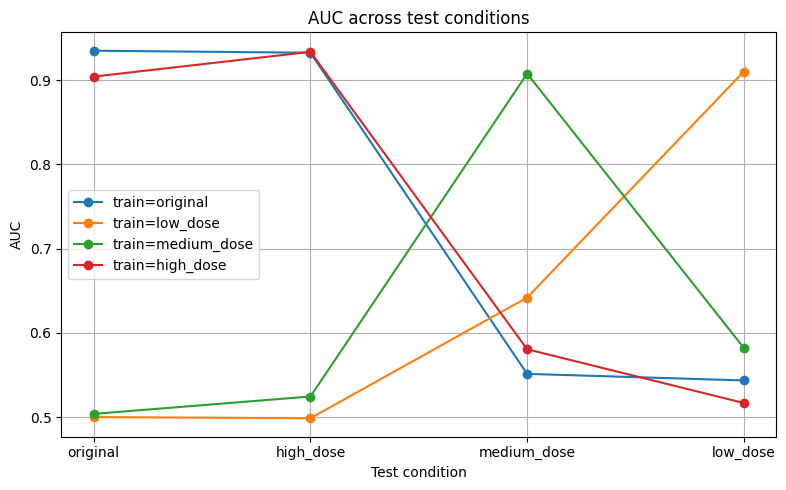

In [31]:
plt.figure(figsize=(8, 5))
for train_condition in results_df["trained_on"].unique():
    subset = results_df[results_df["trained_on"] == train_condition].copy()
    subset["tested_on"] = pd.Categorical(subset["tested_on"], categories=test_order, ordered=True)
    subset = subset.sort_values("tested_on")

    plt.plot(subset["tested_on"], subset["auc"], marker="o", label=f"train={train_condition}")

plt.xlabel("Test condition")
plt.ylabel("AUC")
plt.title("AUC across test conditions")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()